# Len Computar 35 mm

![title](imgs/computar_35mm.jpeg)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

params = {
    'font.family': 'Times New Roman',
    'font.size': 12,
    'mathtext.fontset': 'cm',
    'figure.figsize': (3.48761*2.5,2.3251*2)
}
plt.rcParams.update(params)

def smooth(a, WSZ):
    """
    a: NumPy 1-D array containing the data to be smoothed
    WSZ: smoothing window size needs, which must be odd number,
    as in the original MATLAB implementation
    """
    out0 = np.convolve(a, np.ones(WSZ, dtype=int), "valid") / WSZ
    r = np.arange(1, WSZ - 1, 2)
    start = np.cumsum(a[: WSZ - 1])[::2] / r
    stop = (np.cumsum(a[:-WSZ:-1])[::2] / r)[::-1]
    return np.concatenate((start, out0, stop))

def axplot(ax, x, data, label, color=None):
        ax.plot(x, data, label=label, color=color, linewidth=0.1)
        ax.scatter(x, data, marker='.', color=color, s= 0.5)       


# Extraction of nm 

In [2]:
##########################################################
nm_steps = 1 #5, 10, 20
x_min = 380 # first wavelenght 
x_max = 800 # last wavelenght

##########################################################
data_interp = np.load('data_curves/tau_computar_35mm.npy')
data = np.empty((int((x_max-x_min)/nm_steps),2))

##########################################################
c = 380
data_1, data_2 = list(), list()
for nm in data_interp[:,0]:
    if(nm >= x_min and nm <= x_max and c < x_max):
        data_1.append(data_interp[c-x_min, 1])
        data_2.append(data_interp[c-x_min, 0])
        #print(c)
        c = c + nm_steps
data[:,0] = np.array(data_2)
data[:,1] = np.array(data_1)

##########################################################

findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.


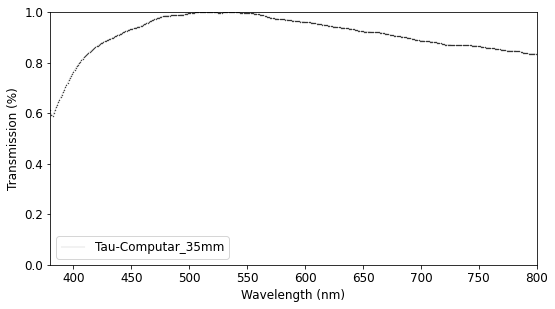

In [3]:
fig, ax = plt.subplots()
axplot(ax, data[:,0],data[:,1] , 'Tau-Computar_35mm',color='black')
ax.set_xlim([x_min,x_max])
ax.set_ylim([0, 1])
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Transmission (%)')
ax.legend()
np.save('tau_computar_35mm_step'+str(nm_steps)+'.npy', data)